In [1]:
from pathlib import Path ## Rutas relativas
from PIL import Image  ## Abrir y manipular imagenes 
from sklearn.cluster import KMeans ##
from sklearn.metrics import silhouette_score
import numpy as np ### Procesar Matrices - Valores de pixeles
import matplotlib.pyplot as plt ## Graficar
import cv2
import numpy as np

**Abrir las imagenes**

In [2]:
def cargar_imagen(image_dir):
    
    image_paths = sorted(
        path for path in image_dir.glob("*")
        if path.is_file()
    )
    print(f"Cant. de imagenes: {len(image_paths)}")
    return image_paths

**Conocer las imagenes**


In [3]:
def tamano_original(image_paths):
    
    for path in image_paths:
        if path.is_file():
            image = cv2.imread(str(path))
            height, width = image.shape[:2]
            print(f"{path.name}: tamaño={width} × {height}")

**Transformacion RGB**

Se incorporó la conversión de BGR a RGB debido a que cv2.imread() carga las imágenes en formato BGR. Esto garantiza una representación RGB consistente antes de realizar el redimensionamiento y la extracción de la paleta mediante K-Means.

In [4]:
def convert_to_rgb(image):
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

**Redimensionamiento de las imágenes**

Las imágenes seleccionadas tienen dimensiones variables, por ejemplo, `3300 × 1382` y `1382 × 1629`. Por esta razón, se realizará un proceso de redimensionamiento (*resize*) antes de utilizarlas en el modelo.

No se utilizará un tamaño fijo para todas las imágenes, ya que esto podría cambiar su relación de aspecto y generar deformaciones. En su lugar, se establecerá un tamaño máximo y cada imagen se redimensionará manteniendo su proporción original.

El objetivo del redimensionamiento es **reducir el número de píxeles que debe procesar K-Means**, haciendo que el algoritmo sea más rápido y requiera menos recursos, pero conservando la información de color de las obras.

Aunque en este ejercicio se trabaja con un número reducido de imágenes, algunas de ellas tienen millones de píxeles. Además, el pipeline debe estar preparado para recibir imágenes nuevas que podrían tener una resolución mucho mayor. Por esta razón, se incluye el redimensionamiento como parte del preprocesamiento, buscando reducir el costo computacional sin perder información relevante para la extracción de la paleta de colores.



**Decisión sobre el factor de reducción**


En lugar de establecer un tamaño fijo para todas las imágenes, se decidió evaluar diferentes **factores de reducción**. Esta decisión permite mantener la proporción original de cada imagen y, al mismo tiempo, analizar cómo la reducción del número de píxeles afecta la información de color y el costo computacional del procesamiento con K-Means. Se probarán los factores **1/2, 1/4, 1/8, 1/16 y 1/32**, donde cada factor se aplica tanto al ancho como al alto de la imagen. De esta forma, la selección del factor final no se realizará de manera arbitraria, sino a partir de la comparación de los resultados obtenidos en términos de conservación de la información y eficiencia computacional.


In [5]:
## Definir la funcion para 
## Calcular los nuevos tama;os segun el factor para redimensionar.
## Redimensionar usando el metodo del area

RESIZE_FACTORS = [1, 1/2, 1/3, 1/4, 1/8, 1/16, 1/32]

def resize_area(image, factor):
    
    height, width = image.shape[:2]
    new_width = int(width * factor)
    new_height = int(height * factor)
    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )
    return resized

Se incluye el factor 1, correspondiente a la imagen original sin reducción, como referencia para evaluar el efecto de los distintos niveles de redimensionamiento. De esta manera, las paletas obtenidas a partir de cada tamaño reducido pueden compararse con la paleta de la imagen original y determinar qué factor permite reducir el número de píxeles manteniendo una representación de color suficientemente similar.

**Reshape y normalizacion**

Posteriormente, las imágenes se transforman mediante un reshape para representar cada píxel como una observación independiente con tres componentes RGB. Finalmente, los valores de los píxeles se normalizan al rango [0,1], dejando los datos en una estructura adecuada para aplicar K-Means.

In [6]:
def flatten_and_normalize(image):

    image = image.reshape((-1, 3))
    image = image / 255.0
    return image

### Pipeline

In [7]:
def preprocesamiento(image_paths, resize_factors):

    processed_images = []

    for path in image_paths:

        # Cargar imagen
        image = cv2.imread(str(path))

        # Convertir a RGB
        image = convert_to_rgb(image)

        # Aplicar cada factor de reducción
        for factor in resize_factors:

            # Resize con AREA
            resized = resize_area(image, factor)

            # Reshape y normalización
            processed = flatten_and_normalize(resized)

            processed_images.append({
                "path": path,
                "factor": factor,
                "image": processed,
                "shape": resized.shape,
                "resized": resized
            })

    return processed_images

**Preparacion de las imagenes**

In [8]:
IMAGE_DIR = Path("data/images")

image_paths = cargar_imagen(IMAGE_DIR)

processed_images = preprocesamiento(
    image_paths,
    RESIZE_FACTORS
)

Cant. de imagenes: 10


In [9]:
for item in processed_images:
    print(
        item["path"].name,
        "| factor:", item["factor"],
        "| shape:", item["image"].shape
    )

albert-bloch_figures-in-silver-light.jpg | factor: 1 | shape: (2289974, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.5 | shape: (572148, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.3333333333333333 | shape: (253920, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.25 | shape: (142830, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.125 | shape: (35604, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.0625 | shape: (8858, 3)
albert-bloch_figures-in-silver-light.jpg | factor: 0.03125 | shape: (2193, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 1 | shape: (2610598, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 0.5 | shape: (652304, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 0.3333333333333333 | shape: (289340, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 0.25 | shape: (162840, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 0.125 | shape: (40592, 3)
albert-gleizes_femme-cubiste-1921.jpg | factor: 0.0625 | shape: (101

In [10]:
def silhouette_plot(X, k_min=2, k_max=10, sample_size=5000, random_state=0):
   
    siluetas = []
    n_muestra = min(sample_size, len(X))

    for i in range(k_min, k_max+1):
        model_k = KMeans(n_clusters=i, max_iter=300, n_init=10, random_state=random_state)
        etiquetas = model_k.fit_predict(X)
        siluetas.append(silhouette_score(X, etiquetas,
                                         sample_size=n_muestra,
                                         random_state=random_state))
    
    k_optimo = range(k_min, k_max+1)[int(np.argmax(siluetas))]

    plt.plot(range(k_min, k_max+1), siluetas, marker='o')
    plt.axvline(k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
    plt.xlabel('Número de clústeres')
    plt.ylabel('Coeficiente de silueta')
    plt.grid()
    plt.legend()
    plt.show()

    return siluetas, k_optimo

Imagen: albert-bloch_figures-in-silver-light.jpg | factor: 0.03125


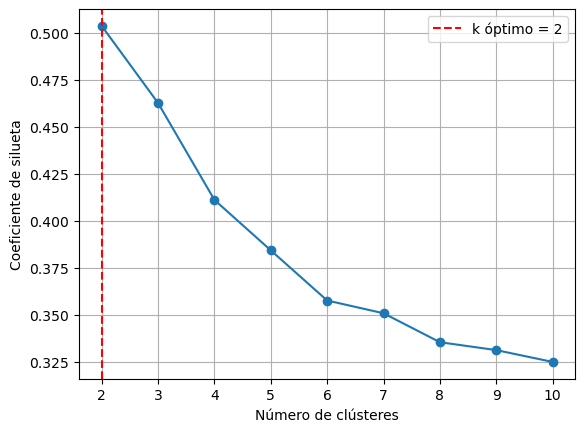

Imagen: albert-gleizes_femme-cubiste-1921.jpg | factor: 0.03125


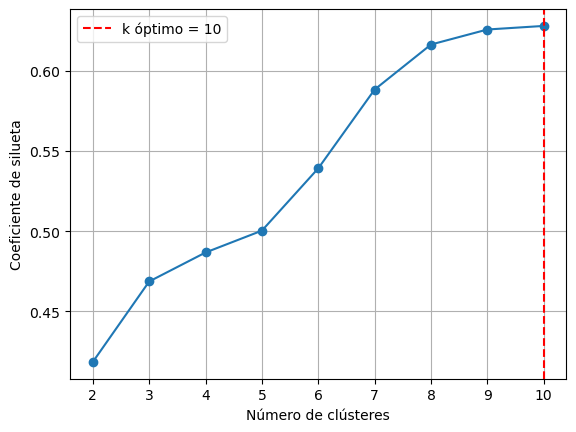

Imagen: aldemir-martins_baiana-1980.jpg | factor: 0.03125


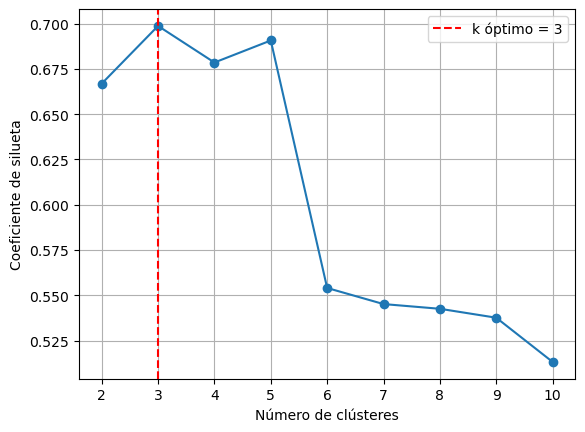

Imagen: aldo-mondino_collage-1973.jpg | factor: 0.03125


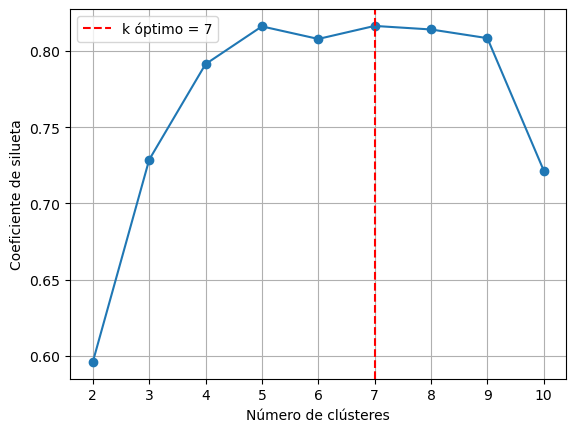

Imagen: aleksey-savrasov_early-spring-2.jpg | factor: 0.03125


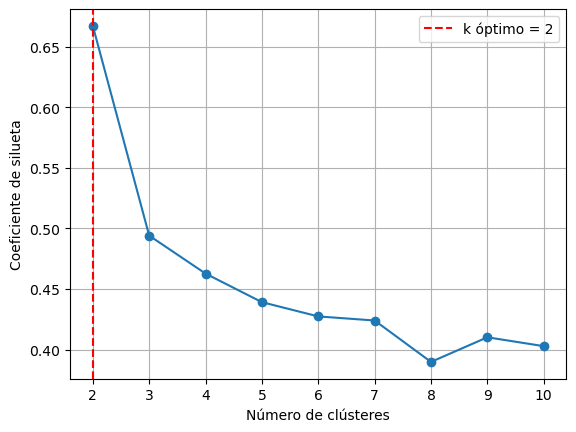

Imagen: alvaro-lapa_c-line-s-notebook-1990.jpg | factor: 0.03125


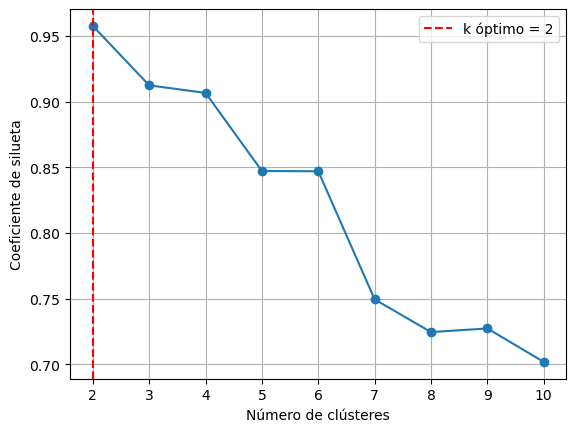

Imagen: andre-derain_the-port-of-collioure-1905.jpg | factor: 0.03125


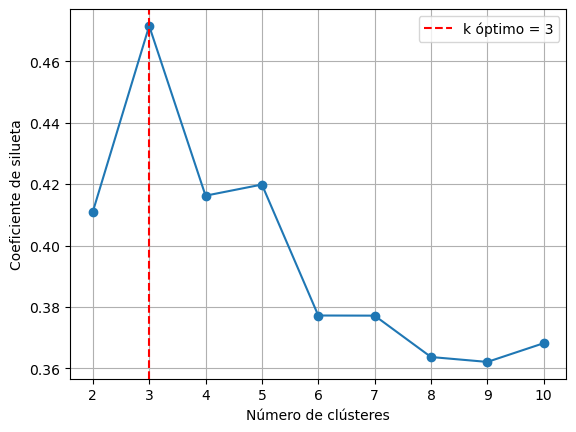

Imagen: betty-parsons_ladder-1968.jpg | factor: 0.03125


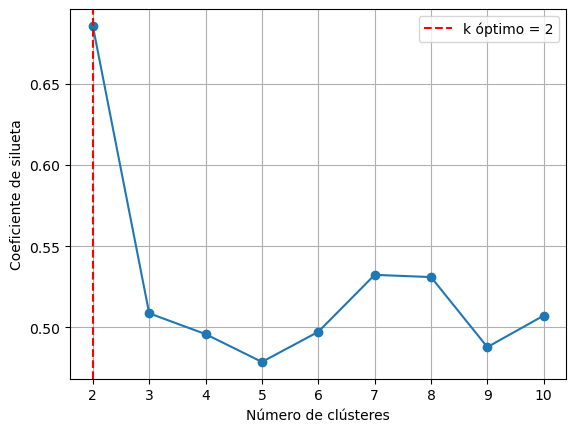

Imagen: joshua-reynolds_jane-fleming-later-countess-of-harrington-1779.jpg | factor: 0.03125


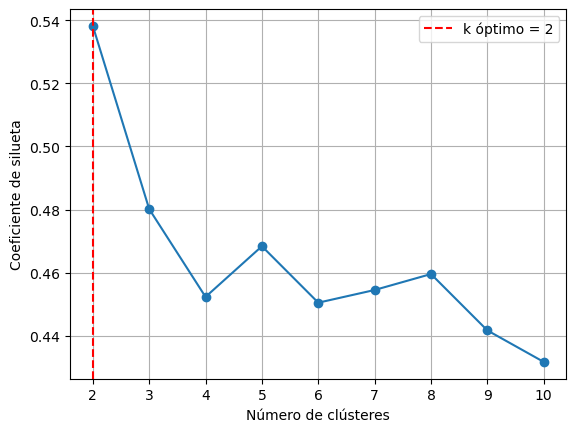

Imagen: yayoi-kusama_fields-in-spring-1988.jpg | factor: 0.03125


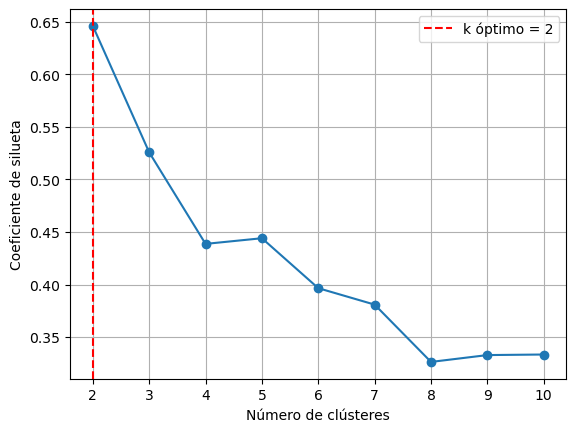

In [11]:
resultados = []

for item in processed_images:
    if item["factor"] != 1/32:
        continue

    X = item["image"]

    print(f'Imagen: {item["path"].name} | factor: {item["factor"]}')
    siluetas, k_optimo = silhouette_plot(X, 2, 10)

    resultados.append({
        "path": item["path"].name,
        "factor": item["factor"],
        "k_optimo": k_optimo
    })

In [12]:
datos = {(item["path"].name, item["factor"]): item["image"] for item in processed_images}

paletas = []

for r in resultados:
    
    X = datos[(r["path"], r["factor"])]

    item = next(i for i in processed_images
                if i["path"].name == r["path"] and i["factor"] == r["factor"])

    modelo = KMeans(n_clusters=r["k_optimo"], max_iter=300, n_init=10, random_state=0)
    etiquetas = modelo.fit_predict(X)

    paletas.append({
        "path": r["path"],
        "factor": r["factor"],
        "colores": modelo.cluster_centers_,
        "etiquetas": etiquetas,
        "shape": item["shape"],
        "resized": item["resized"],
        "k_optimo": r["k_optimo"],
        "modelo": modelo
    })

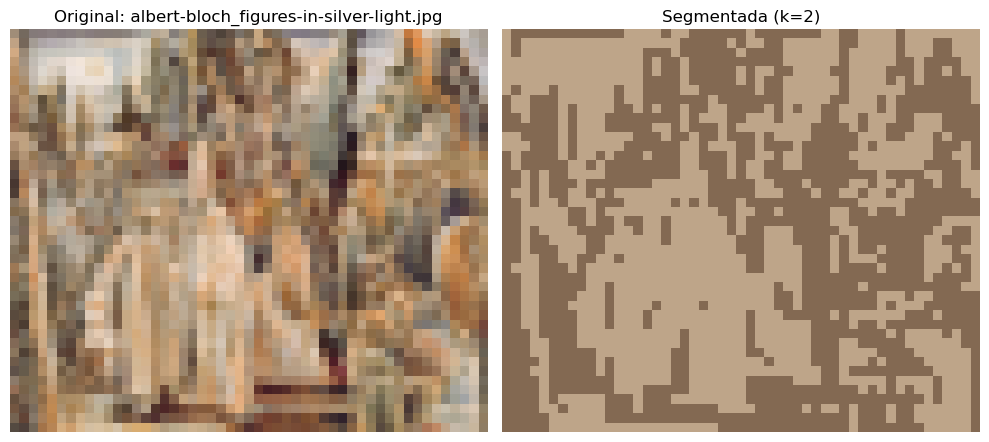

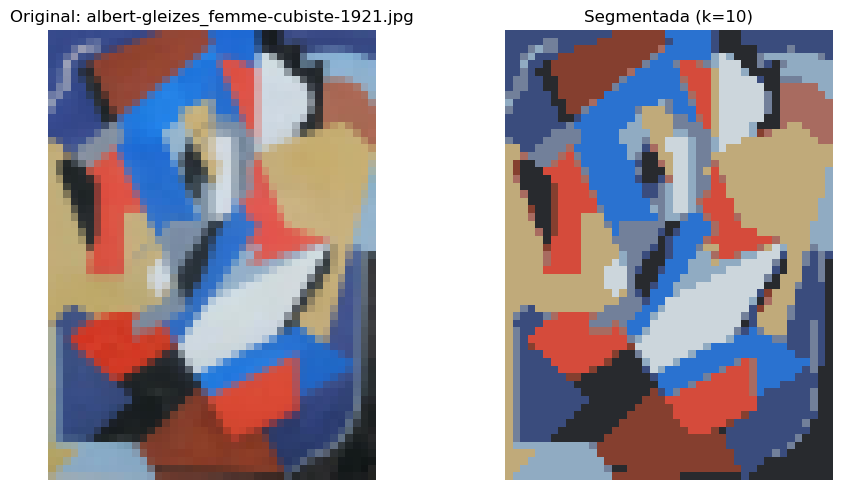

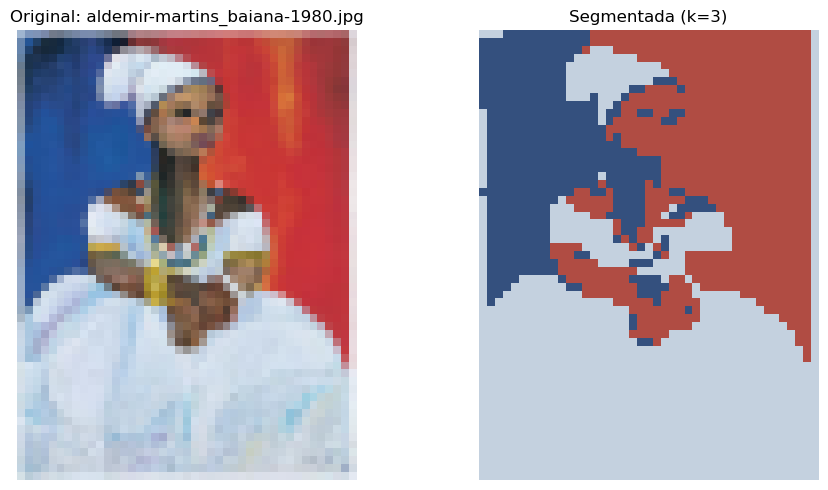

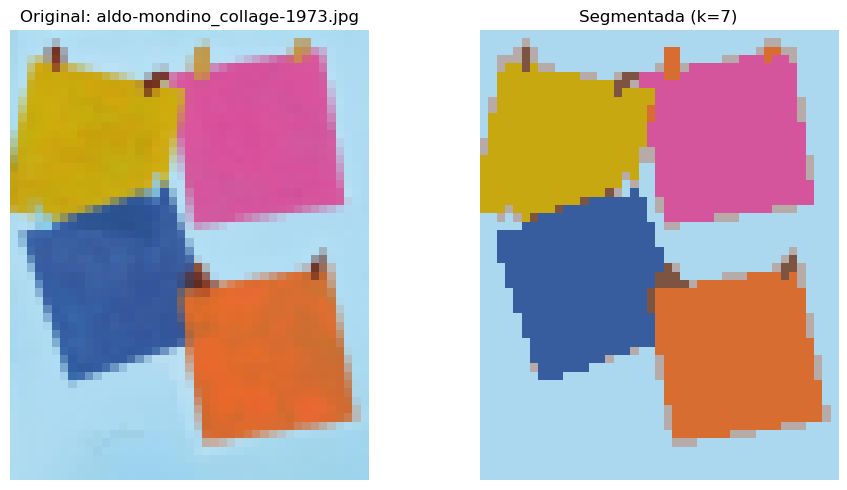

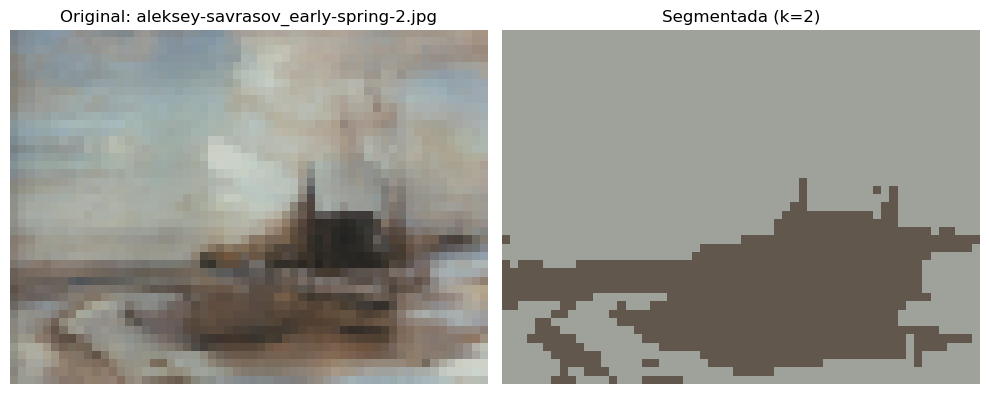

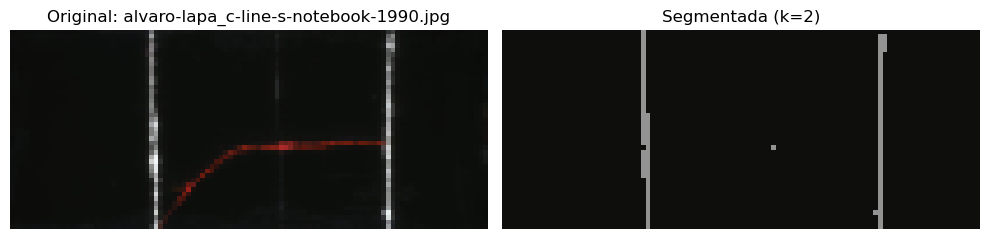

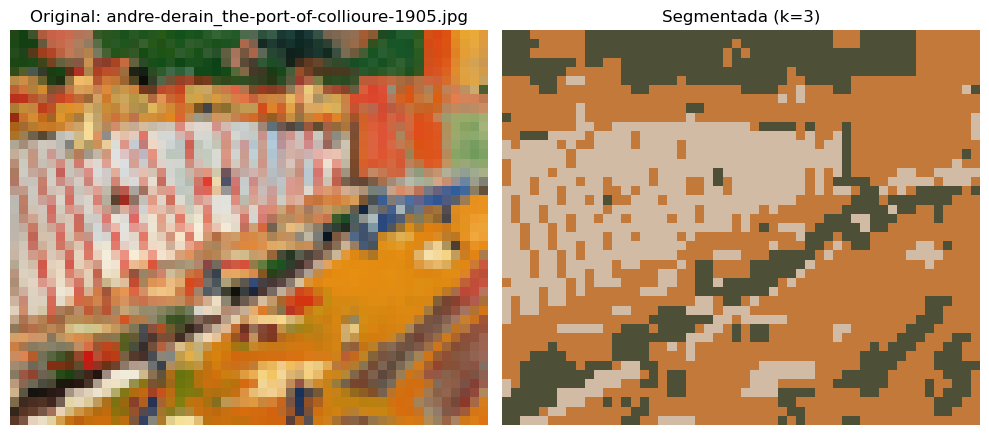

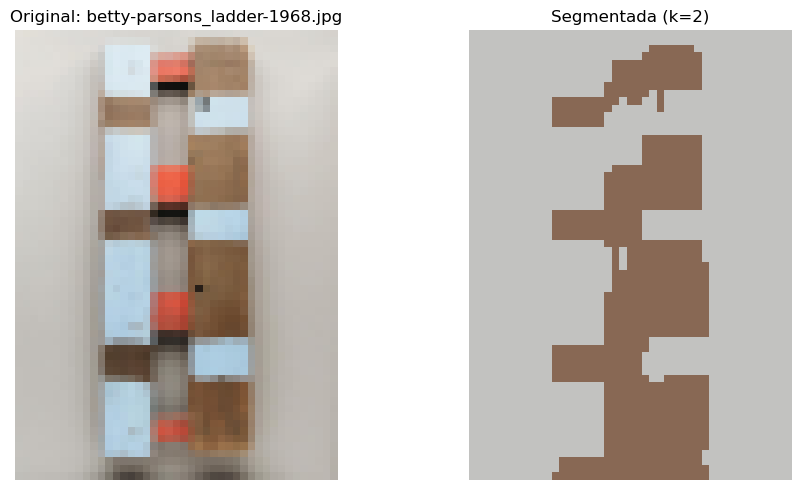

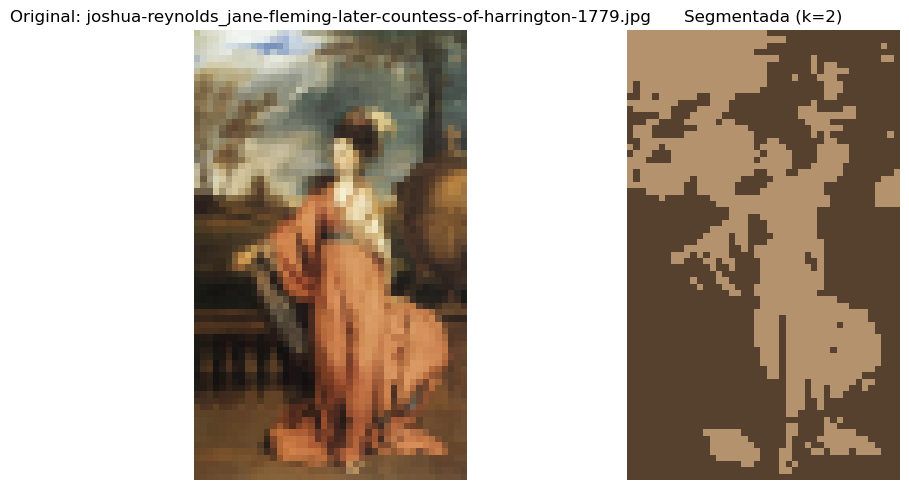

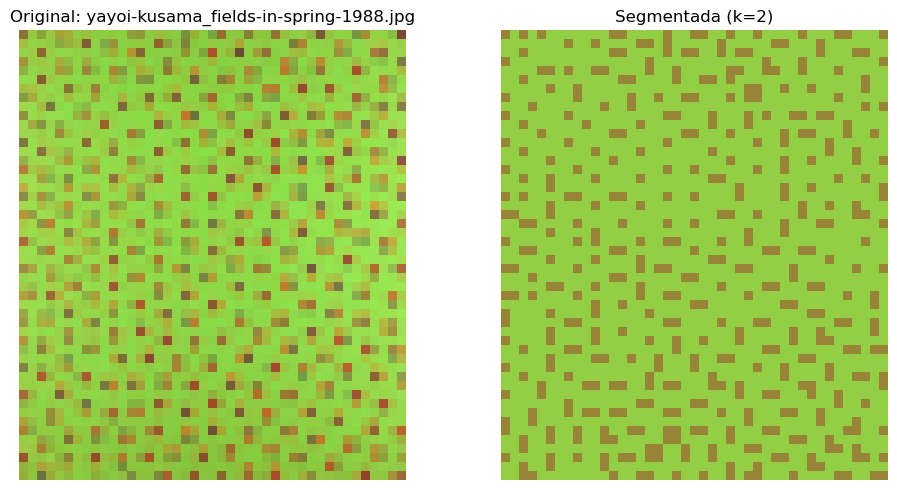

In [13]:
for p in paletas:
    centroids = p["colores"]
    labels = p["etiquetas"]
    target_shape = p["shape"]
    img_original = p["resized"]

    img_segmentada = (centroids[labels] * 255).reshape(target_shape).astype(np.uint8)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title(f'Original: {p["path"]}')
    plt.imshow(img_original)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f'Segmentada (k={p["k_optimo"] if "k_optimo" in p else "?"})')
    plt.imshow(img_segmentada)
    plt.axis('off')

    plt.tight_layout()
    plt.show()